In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Machine Learning para Regresión
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configuración visual de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# URL del dataset oficial de seguros médicos
data_url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"

# Carga de datos original
df = pd.read_csv(data_url)
print("¡Dataset de seguros médicos cargado con éxito!")
display(df.head())

¡Dataset de seguros médicos cargado con éxito!


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


EDA - Inspección Inicial y Limpieza de Datos

In [7]:
print("Estructura y Tipos de Datos Originales")
print(df.info())


Estructura y Tipos de Datos Originales
<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB
None


In [8]:
print("\n 2. Verificación de Valores Nulos ")
print(df.isnull().sum())

# Comprobación y eliminación de duplicados para evitar sobreajuste
duplicados = df.duplicated().sum()
print(f"\n 3. Registros Duplicados Detectados: {duplicados} ")
if duplicados > 0:
    df = df.drop_duplicates()
    print(f"Dimensiones del DataFrame tras limpiar duplicados: {df.shape}")


 2. Verificación de Valores Nulos 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

 3. Registros Duplicados Detectados: 0 


EDA - Análisis Univariante (Variable Objetivo charges)

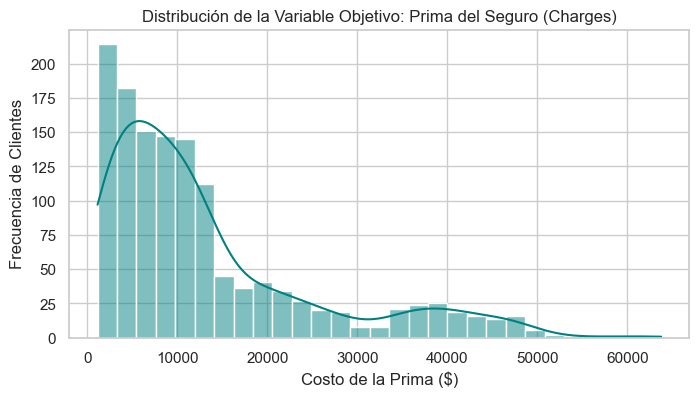

Resumen estadístico descriptivo de los costos:
count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64


In [5]:
# Es necesario saber analizar cómo se distribuye la variable que queremos predecir
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='charges', kde=True, color='teal')
plt.title('Distribución de la Variable Objetivo: Prima del Seguro (Charges)')
plt.xlabel('Costo de la Prima ($)')
plt.ylabel('Frecuencia de Clientes')
plt.show()

print("Resumen estadístico descriptivo de los costos:")
print(df['charges'].describe())

Este gráfico es un histograma con una curva de estimación de densidad de kernel (KDE) y analiza la distribución de la variable objetivo, que en este caso es charges (la prima del seguro médico), aqui podemos observar: 

1. Sesgo a la derecha (Asimetría Positiva)
La distribución no es una campana de Gauss normal o simétrica. Está fuertemente sesgada a la derecha. Esto significa que:

La gran mayoría de los clientes de la aseguradora pagan primas bajas o moderadas (concentradas entre los $1,000 y los $15,000). A medida que el costo aumenta, la frecuencia de clientes disminuye drásticamente.

2. Comportamiento Bimodal / Multimodal (Los "picos" secundarios)
Si te fijas bien en la curva, la distribución intenta levantarse un poco de nuevo en ciertas zonas: Hay un pequeño repunte cerca de los $35,000 - $40,000. Esto indica la presencia de subgrupos bien diferenciados dentro de los datos.

3. Impacto para el modelo de Regresión Lineal

Valores atípicos (Outliers): Los costos que superan los $50,000 son poco comunes pero existen. La regresión lineal es muy sensible a estos valores altos porque intentará minimizar el error cuadrático medio (MSE), lo que podría "jalar" la línea de predicción hacia arriba.

EDA - Análisis Bivariante (Relación de Características vs Costo)

C:\Users\PC\AppData\Local\Temp\ipykernel_19364\3110856630.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='Set1')


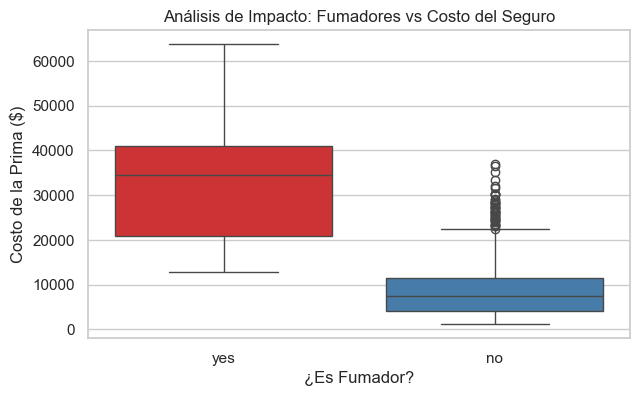

In [15]:
# Gráfico 1: Impacto de ser fumador en el costo del seguro
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set1')
plt.title('Análisis de Impacto: Fumadores vs Costo del Seguro')
plt.xlabel('¿Es Fumador?')
plt.ylabel('Costo de la Prima ($)')
plt.show()



# Impacto de Fumadores vs Costo del Seguro 

Este boxplot compara la distribución del costo de la prima (charges) dividiendo a los clientes entre los que fuman (yes) y los que no (no).

Diferencia Drástica en la Mediana: La línea central de la caja roja (fumadores) se sitúa cerca de los $35,000, mientras que la de la caja azul (no fumadores) está por debajo de los $10,000. 

Esto demuestra visualmente que el tabaquismo es, probablemente, el factor individual que más encarece el seguro médico.

Dispersión y Rangos: El 50% central de los fumadores se concentra en un rango alto, entre los $20,000 y los $41,000 aproximadamente. En cambio, los no fumadores se concentran fuertemente en costos bajos.

Valores Atípicos: En el grupo de los no fumadores, vemos muchos puntos negros por encima del bigote superior (entre $22,000 y $37,000). Estos son valores atípicos para ese grupo específico. Significa que, aunque no fumen, hay ciertos clientes que tienen costos altos debido a otras complicaciones (como la edad o un BMI muy alto).

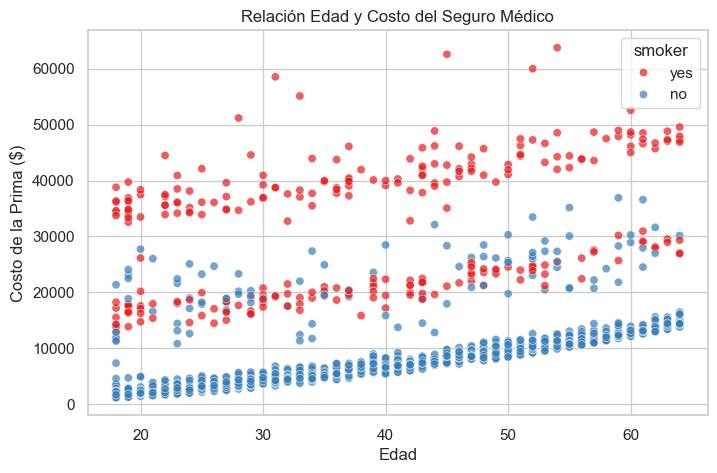

In [16]:
# Gráfico 2: Relación entre la Edad y el Costo (Diferenciando por Fumador)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7, palette='Set1')
plt.title('Relación Edad y Costo del Seguro Médico')
plt.xlabel('Edad')
plt.ylabel('Costo de la Prima ($)')
plt.show()

Relación Edad y Costo del Seguro Médico  

Este scatterplot cruza la edad en el eje X con el costo en el eje Y, utilizando el color para identificar si el cliente es fumador (rojo) o no (azul). Nos muestra un comportamiento interesante en la estructura de estos datos:

 - Las "Tres Capas" de Costo: Los datos se alinean visualmente en tres franjas o líneas diagonales muy claras que crecen de izquierda a derecha a medida que avanza la edad:

-Franja Inferior (Azul): Clientes no fumadores y sanos. Sus costos aumentan de forma perfectamente lineal y predecible con los años (desde unos $2,000 a los 18 años hasta cerca de $15,000 a los 64 años).

-Franja Intermedia (Mezcla de Azul y Rojo): Aquí vemos no fumadores con complicaciones de salud y fumadores que quizás son jóvenes o no tienen un índice de masa corporal alarmante. Sus costos van de los $12,000 a los $30,000.

-Franja Superior (Rojo pura): Clientes fumadores con alto riesgo (alto BMI y/o edad avanzada). Sus costos se disparan por las nubes, arrancando desde los $35,000 hasta superar los $60,000.

- El efecto de la Edad: En las tres franjas se aprecia una pendiente positiva constante. Esto le confirma a tu modelo de regresión que la edad siempre aumenta el costo, pero el multiplicador real (lo que determina en qué franja caes) es el tabaco.

Ingeniería de Características 

In [10]:
# 1. Creamos una copia de trabajo para realizar las transformaciones
df_features = df.copy()

# 2. Variables Categóricas Binarias -> Mapeo manual controlado a 0 y 1
df_features['sex'] = df_features['sex'].map({'female': 0, 'male': 1})
df_features['smoker'] = df_features['smoker'].map({'no': 0, 'yes': 1})
print("-> Variables 'sex' y 'smoker' transformadas correctamente.")

# 3. Variable Categórica Multi-clase ('region') -> One-Hot Encoding
# Evita el error de asignar un orden artificial (0,1,2,3) usando variables dummy
df_features = pd.get_dummies(df_features, columns=['region'], drop_first=True, dtype=int)
print("-> Variable 'region' codificada con One-Hot Encoding (drop_first=True).")

# 4. Escalado de Variables Numéricas Continuas
#  Se usa StandardScaler para normalizar la escala de las variables numéricas
scaler = StandardScaler()
num_cols = ['age', 'bmi', 'children']
df_features[num_cols] = scaler.fit_transform(df_features[num_cols])
print("-> Variables numéricas continuas normalizadas con StandardScaler.")

print("\nDATOS FINALES PROCESADOS PARA MODELADO:")
display(df_features.head())

-> Variables 'sex' y 'smoker' transformadas correctamente.
-> Variable 'region' codificada con One-Hot Encoding (drop_first=True).
-> Variables numéricas continuas normalizadas con StandardScaler.

DATOS FINALES PROCESADOS PARA MODELADO:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,-1.440418,0,-0.453160,-0.909234,1,16884.92400,0,0,1
1,-1.511647,1,0.509422,-0.079442,0,1725.55230,0,1,0
2,-0.799350,1,0.383155,1.580143,0,4449.46200,0,1,0
3,-0.443201,1,-1.305052,-0.909234,0,21984.47061,1,0,0
4,-0.514431,1,-0.292456,-0.909234,0,3866.85520,1,0,0


 División del Conjunto de Datos (Train / Test Split)

In [11]:
# Separamos las variables predictoras (X) de la variable objetivo (y)
X = df_features.drop(columns=['charges'])
y = df_features['charges']

# División clásica: 80% Entrenamiento y 20% Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de Entrenamiento (Train): {X_train.shape[0]} muestras con {X_train.shape[1]} columnas.")
print(f"Set de Prueba (Test): {X_test.shape[0]} muestras.")

Set de Entrenamiento (Train): 1069 muestras con 8 columnas.
Set de Prueba (Test): 268 muestras.


Construcción y Evaluación del Modelo Base (Regresión Lineal)

In [13]:
# Se inicia y entrena  el modelo lineal clásico
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Realizamos las predicciones sobre el conjunto de prueba
y_pred_base = baseline_model.predict(X_test)

# Cálculo de métricas de regresión obligatorias
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

print(" EVALUACIÓN DEL MODELO BASE ")
print(f"MAE (Error Absoluto Medio): {mae_base:.2f} $")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_base:.2f} $")
print(f"R² Score (Precisión de ajuste): {r2_base:.4f} ({r2_base*100:.2f}%)")

 EVALUACIÓN DEL MODELO BASE 
MAE (Error Absoluto Medio): 4177.05 $
RMSE (Raíz del Error Cuadrático Medio): 5956.34 $
R² Score (Precisión de ajuste): 0.8069 (80.69%)


Optimización del Modelo (Regresión Ridge) y Gráfico de Diagnóstico 

 EVALUACIÓN DEL MODELO OPTIMIZADO (RIDGE)
R² Score Optimizado: 0.8059


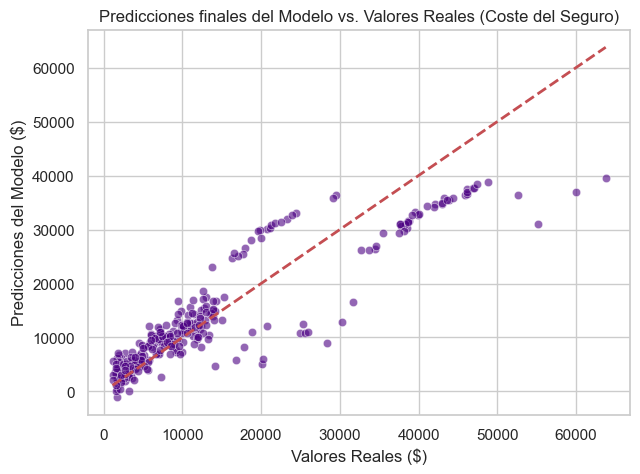

In [14]:
# Aplicar Regularización Ridge (Penalización L2) para mejorar la estabilidad del modelo
optimized_model = Ridge(alpha=1.0)
optimized_model.fit(X_train, y_train)

# Predicciones finales
y_pred_opt = optimized_model.predict(X_test)

print(" EVALUACIÓN DEL MODELO OPTIMIZADO (RIDGE)")
print(f"R² Score Optimizado: {r2_score(y_test, y_pred_opt):.4f}")

# Gráfico final de control: Valores Reales vs Predicciones
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_opt, alpha=0.6, color='indigo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Predicciones finales del Modelo vs. Valores Reales (Coste del Seguro)')
plt.xlabel('Valores Reales ($)')
plt.ylabel('Predicciones del Modelo ($)')
plt.show()

1. Interpretación de la Línea de Referencia 
La línea discontinua representa la predicción perfecta. Si el modelo fuera infalible y acertara el costo exacto de cada cliente, todos los puntos de color morado estarían situados exactamente encima de esa línea roja.

2. Comportamiento en Costos Bajos y Medios 
En el rango de $0 a $15,000, la nube de puntos se agrupa de forma bastante compacta alrededor de la línea roja.

Esto demuestra que para la gran mayoría de la población (los asegurados estándar y no fumadores), el modelo es muy preciso y predice los costos con un margen de error bastante bajo.

3. Fallo Sistemático en Costos Altos (Subestimación)
A partir de los $20,000, ocurre un fenómeno muy claro: los puntos se separan de la línea de referencia y forman dos hileras diagonales que se quedan por debajo de la línea roja.

Esto significa que el modelo sufre de subestimación en los casos de alto costo (fumadores o personas con riesgos de salud complejos). Cuando alguien en la realidad cuesta $40,000 o $60,000, el modelo tiende a predecir que costará menos (máximo entre $35,000 y $40,000).

Las dos líneas paralelas que se aprecian sugieren que hay una interacción fuerte que la simple regresión lineal por separado no logra curvar del todo (probablemente la combinación letal de bmi alto junto con ser smoker).